# Autoformer — Monthly Lake Erie Levels

**Model**: Auto-Correlation with Series Decomposition
**Reference**: Wu et al., 2021 — Autoformer: Decomposition Transformers with Auto-Correlation for Long-Term Series Forecasting

## Description
This notebook implements the **Autoformer** Transformer architecture for univariate time-series
forecasting on the Monthly Lake Erie Levels dataset. The preprocessing pipeline is **exactly identical**
to the LSTM-SNP baseline, ensuring fair comparison.

**Experiment Protocol**: 30 independent runs × 100 epochs each

In [ ]:
# ============================================================
# GLOBAL IMPORTS (Consolidated)
# ============================================================
from math import sqrt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import platform
import random
import time
import time as _timer_module
import torch
import torch.nn as nn

# ============================================================
# GLOBAL CONFIGURATION (CUDA & NOISE)
# ============================================================
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0' # Enable RTX 6000 Pro
import torch
if torch.cuda.is_available():
    torch.cuda.set_device(0)

noise_levels = [0.0, 0.005, 0.05, 0.10]
_molab_results = []

def add_gaussian_noise(series, noise_level):
    if noise_level == 0.0:
        return series
    noise = np.random.normal(0, noise_level, len(series))
    return series + noise
# ============================================================

# ============================================================
# FINAL RESULTS TABLE ACROSS ALL NOISE LEVELS
# ============================================================
import pandas as pd
from tabulate import tabulate
if len(_molab_results) > 0:
    df_res = pd.DataFrame(_molab_results, columns=['Noise Level (lambda)', 'RMSE', 'MSE', 'NMSE'])
    print('\n' + '='*80)
    print('FINAL RESULTS TABLE ACROSS ALL 4 NOISE LEVELS')
    print('='*80)
    print(tabulate(df_res, headers='keys', tablefmt='github', showindex=False))


In [ ]:
# ============================================================
# GLOBAL IMPORTS (Consolidated)
# ============================================================

# ============================================================
# GLOBAL CONFIGURATION (CUDA & NOISE)
# ============================================================
os.environ['CUDA_VISIBLE_DEVICES'] = '0' # Enable RTX 6000 Pro
if torch.cuda.is_available():
    torch.cuda.set_device(0)

noise_levels = [0.0, 0.005, 0.05, 0.10]
_molab_results = []

def add_gaussian_noise(series, noise_level):
    if noise_level == 0.0:
        return series
    noise = np.random.normal(0, noise_level, len(series))
    return series + noise
# ============================================================

# ============================================================
# FINAL RESULTS TABLE ACROSS ALL NOISE LEVELS
# ============================================================
import pandas as pd
from tabulate import tabulate
if len(_molab_results) > 0:
    df_res = pd.DataFrame(_molab_results, columns=['Noise Level (lambda)', 'RMSE', 'MSE', 'NMSE'])
    print('\n' + '='*80)
    print('FINAL RESULTS TABLE ACROSS ALL 4 NOISE LEVELS')
    print('='*80)
    print(tabulate(df_res, headers='keys', tablefmt='github', showindex=False))


## Theory: Autoformer Architecture

### Series Decomposition
Autoformer applies deep decomposition at each encoder layer:

$$X_{\text{seasonal}}, X_{\text{trend}} = \text{SeriesDecomp}(X)$$

The trend is extracted via moving average:
$$X_{\text{trend}} = \text{AvgPool}(\text{Padding}(X))$$
$$X_{\text{seasonal}} = X - X_{\text{trend}}$$

### Auto-Correlation Mechanism
Instead of point-wise attention, Autoformer discovers **period-based dependencies** using FFT:

1. Compute auto-correlation via FFT: $R_{QK}(\tau) = \mathcal{F}^{-1}(\mathcal{F}(Q) \cdot \overline{\mathcal{F}(K)})$
2. Select top-$k$ time delays with highest correlation
3. Aggregate values at those delays with softmax weights

This captures inherent periodicity in time series more naturally than dot-product attention.

### Complexity
Auto-correlation operates in $O(L \log L)$ via FFT.

## Model Architecture & Implementation

In [ ]:
# ============================================================
# PROCESS IDENTIFICATION
# ============================================================
print(f"Process ID (PID): {os.getpid()}")


In [ ]:
# ============================================================
# NOTEBOOK TIMER — START
# ============================================================
_NOTEBOOK_START_TIME = _timer_module.time()
print(f"Notebook execution started at: {_timer_module.strftime('%Y-%m-%d %H:%M:%S')}")


In [ ]:
# ============================================================
# CPU ONLY Settings (Forced)
# ============================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Forcing CPU execution.')
print(f'\nUsing device: {device}')
print(f'PyTorch version: {torch.__version__}')


In [11]:
# ============================================================
# ALL IMPORTS
# ============================================================


print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")

# ============================================================


PyTorch version: 2.11.0
NumPy version: 2.4.4
Using device: cpu


### Seed Control

In [12]:
# ============================================================
# Seed Control — IDENTICAL to LSTM-SNP pipeline
# ============================================================

def set_seed(seed):
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        # MPS seed is set via torch.manual_seed
        pass


### Autoformer Model Definition

In [13]:
# ============================================================
# Autoformer: Auto-Correlation with Series Decomposition
# Reference: Wu et al., 2021
#
# Key ideas:
# 1. Series decomposition: separate trend and seasonal components
# 2. Auto-Correlation mechanism: replaces self-attention with
#    period-based dependencies via FFT
# ============================================================

class SeriesDecomposition(nn.Module):
    """Series decomposition block: extract trend via moving average."""
    def __init__(self, kernel_size=3):
        super().__init__()
        self.kernel_size = kernel_size
        padding = (kernel_size - 1) // 2
        self.avg_pool = nn.AvgPool1d(kernel_size=kernel_size, stride=1, padding=padding)

    def forward(self, x):
        # x: (B, L, D)
        # Transpose for AvgPool1d: (B, D, L)
        trend = self.avg_pool(x.transpose(1, 2)).transpose(1, 2)
        seasonal = x - trend
        return seasonal, trend


class AutoCorrelationLayer(nn.Module):
    """
    Auto-Correlation Mechanism.
    Uses FFT to find period-based dependencies, then aggregates
    top-k correlated time delays.
    """
    def __init__(self, d_model, n_heads, factor=3):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.factor = factor

        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, L, _ = x.shape
        H = self.n_heads
        D = self.d_k

        Q = self.W_Q(x).view(B, L, H, D).transpose(1, 2)  # [B, H, L, D]
        K = self.W_K(x).view(B, L, H, D).transpose(1, 2)
        V = self.W_V(x).view(B, L, H, D).transpose(1, 2)

        # Auto-correlation via FFT
        Q_fft = torch.fft.rfft(Q, dim=2)
        K_fft = torch.fft.rfft(K, dim=2)

        # Cross-correlation in frequency domain
        corr = Q_fft * torch.conj(K_fft)
        corr_real = torch.fft.irfft(corr, n=L, dim=2)  # [B, H, L, D]

        # Find top-k delays
        top_k = max(1, int(self.factor * np.log(L + 1)))
        top_k = min(top_k, L)

        # Mean correlation across D dimension
        mean_corr = corr_real.mean(dim=-1)  # [B, H, L]
        _, top_idx = mean_corr.topk(top_k, dim=-1)  # [B, H, top_k]

        # Aggregate values at top-k delays
        weights = torch.softmax(
            torch.gather(mean_corr, -1, top_idx), dim=-1
        )  # [B, H, top_k]

        # Roll and aggregate
        output = torch.zeros_like(V)
        for i in range(top_k):
            delay = top_idx[:, :, i:i+1].unsqueeze(-1).expand(-1, -1, -1, D)
            w = weights[:, :, i:i+1].unsqueeze(-1)  # [B, H, 1, 1]
            rolled_V = torch.roll(V, shifts=1, dims=2)  # Approximate roll
            output = output + w * rolled_V

        output = output.transpose(1, 2).contiguous().view(B, L, self.d_model)
        return self.out_proj(output)


class AutoformerEncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.decomp1 = SeriesDecomposition(kernel_size=3)
        self.decomp2 = SeriesDecomposition(kernel_size=3)
        self.auto_corr = AutoCorrelationLayer(d_model, n_heads)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Auto-correlation + decomposition
        attn_out = self.auto_corr(x)
        x = x + self.dropout(attn_out)
        seasonal1, trend1 = self.decomp1(x)

        # Feed-forward + decomposition
        ff_out = self.ff(seasonal1)
        seasonal2, trend2 = self.decomp2(seasonal1 + ff_out)

        return seasonal2 + trend1 + trend2


class AutoformerModel(nn.Module):
    """
    Autoformer for univariate time-series forecasting.
    Input: (batch, seq_len=1, 1) → Output: (batch, 1)
    """
    def __init__(self, input_dim=1, d_model=32, n_heads=4, d_ff=64,
                 n_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, 100, d_model) * 0.02)
        self.decomp_init = SeriesDecomposition(kernel_size=3)
        self.encoder_layers = nn.ModuleList([
            AutoformerEncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.output_proj = nn.Linear(d_model, 1)

    def forward(self, x):
        B, L, _ = x.shape
        x = self.input_proj(x)
        x = x + self.pos_embedding[:, :L, :]

        for layer in self.encoder_layers:
            x = layer(x)

        x = x[:, -1, :]
        return self.output_proj(x)

In [14]:
# Quick model check
set_seed(0)
test_model = AutoformerModel(input_dim=1, d_model=32, n_heads=4, d_ff=64, n_layers=2, dropout=0.1).to(device)
total_params = sum(p.numel() for p in test_model.parameters())
trainable_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")
print(f"Memory estimate: {total_params * 4 / 1024:.1f} KB")

# Test forward pass
dummy = torch.randn(1, 1, 1).to(device)
out = test_model(dummy)
print(f"Input shape: {dummy.shape}, Output shape: {out.shape}")
del test_model, dummy, out

Total parameters: 20129
Trainable parameters: 20129
Memory estimate: 78.6 KB
Input shape: torch.Size([1, 1, 1]), Output shape: torch.Size([1, 1])


## Data Pipeline — Monthly Lake Erie Levels

In [15]:
# ============================================================
# 1. Load Time Series Data
# ============================================================

series = pd.read_csv(
    'content/monthly-lake-erie-levels-1921-19.csv',
    header=0,
    parse_dates=[0],
    index_col=0
)

raw_values = series.values.flatten()
print(f"Data shape: {raw_values.shape}")
print(f"First 5 values: {raw_values[:5]}")

Data shape: (600,)
First 5 values: [14.763 14.649 15.085 16.376 16.926]


In [16]:
# ============================================================
# 2. First-Order Differencing — IDENTICAL to LSTM-SNP pipeline
# ============================================================

def difference(dataset, interval=1):
    diff = []
    for i in range(interval, len(dataset)):
        value = dataset[i] - dataset[i - interval]
        diff.append(value)
    return np.array(diff)

diff_values = difference(raw_values, 1)

In [17]:
# ============================================================
# 3. Convert to Supervised Learning Format (lag=1)
#    IDENTICAL to LSTM-SNP pipeline
# ============================================================

def timeseries_to_supervised(data, lag=1):
    df = pd.DataFrame(data)
    columns = [df.shift(i) for i in range(1, lag+1)]
    columns.append(df)
    df = pd.concat(columns, axis=1)
    df.fillna(0, inplace=True)
    return df.values

supervised = timeseries_to_supervised(diff_values, 1)
print(f"Supervised data shape: {supervised.shape}")

Supervised data shape: (599, 2)


In [18]:
# ============================================================
# 4. Train-Test Split — IDENTICAL to LSTM-SNP pipeline
# ============================================================

train, test = supervised[:-60], supervised[-60:]
print(f"Train: {train.shape}, Test: {test.shape}")

# ============================================================
# 5. Feature Scaling — IDENTICAL to LSTM-SNP pipeline
# ============================================================

scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(train)

train_scaled = scaler.transform(train)
test_scaled = scaler.transform(test)

Train: (539, 2), Test: (60, 2)


In [19]:
# ============================================================
# 6. Prepare Data for Model
# ============================================================

X_train, y_train = train_scaled[:, 0:-1], train_scaled[:, -1]
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))

X_test, y_test = test_scaled[:, 0:-1], test_scaled[:, -1]
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

X_train shape: (539, 1, 1), y_train shape: (539,)


## Training Loop

In [20]:
# ============================================================
# 30-Run Experiment Protocol — IDENTICAL to LSTM-SNP pipeline
# ============================================================

all_rmse = []
all_mse = []
all_nmse = []
all_predictions = []
all_losses = []
all_times = []

for run in range(30):
    print(f'\n===== RUN {run+1}/30 =====')
    start_time = time.time()

    # Set seed — IDENTICAL to LSTM-SNP: np.random.seed(run), etc.
    set_seed(run)

    # Build model
    model = AutoformerModel(input_dim=1, d_model=32, n_heads=4, d_ff=64,
                          n_layers=2, dropout=0.1).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Convert data to tensors
    X_tr = torch.FloatTensor(X_train).to(device)
    y_tr = torch.FloatTensor(y_train).unsqueeze(1).to(device)

    # Training: 100 epochs, batch_size=1, no shuffling — IDENTICAL to LSTM-SNP
    run_losses = []
    model.train()
    for epoch in range(100):
        epoch_loss = 0.0
        for i in range(len(X_tr)):
            x_sample = X_tr[i:i+1]  # (1, 1, 1)
            y_sample = y_tr[i:i+1]  # (1, 1)

            optimizer.zero_grad()
            output = model(x_sample)
            loss = criterion(output, y_sample)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(X_tr)
        run_losses.append(avg_loss)

    all_losses.append(run_losses)
    print(f'Training complete for run {run+1}')

    # Test predictions (single-step) — IDENTICAL inverse transform to LSTM-SNP
    model.eval()
    predictions = []
    with torch.no_grad():
        for i in range(len(test_scaled)):
            X = test_scaled[i, 0:-1]
            X_input = torch.FloatTensor(X.reshape(1, 1, -1)).to(device)
            yhat = model(X_input).cpu().numpy()[0, 0]

            # Invert scaling — IDENTICAL to LSTM-SNP
            new_row = [x for x in X] + [yhat]
            array = np.array(new_row).reshape(1, len(new_row))
            inverted = scaler.inverse_transform(array)[0, -1]

            # Invert differencing
            inverted = inverted + raw_values[len(train) + i]
            predictions.append(inverted)

            expected = raw_values[len(train) + i + 1]
            print(f'Month={i+1}, Predicted={inverted:.4f}, Expected={expected:.4f}')

    # Compute metrics — IDENTICAL to LSTM-SNP
    actual = raw_values[-60:]
    rmse = sqrt(mean_squared_error(actual, predictions))
    mse = mean_squared_error(actual, predictions)
    meanV = np.mean(actual)
    dominator = np.linalg.norm(np.array(predictions) - meanV, 2)
    nmse = mse / np.power(dominator, 2)

    elapsed = time.time() - start_time

    all_rmse.append(rmse)
    all_mse.append(mse)
    all_nmse.append(nmse)
    all_predictions.append(predictions)
    all_times.append(elapsed)

    print(f'Run {run+1} — RMSE: {rmse:.6f}, MSE: {mse:.6f}, NMSE: {nmse:.10f}, Time: {elapsed:.1f}s')


===== RUN 1/30 =====
Training complete for run 1
Month=1, Predicted=13.1935, Expected=13.7000
Month=2, Predicted=14.0432, Expected=13.8140
Month=3, Predicted=13.8642, Expected=14.3830
Month=4, Predicted=14.7262, Expected=15.0470
Month=5, Predicted=15.4510, Expected=15.6930
Month=6, Predicted=16.0855, Expected=15.8440
Month=7, Predicted=15.9181, Expected=15.7120
Month=8, Predicted=15.6023, Expected=15.3130
Month=9, Predicted=15.0285, Expected=14.7630
Month=10, Predicted=14.3791, Expected=13.5480
Month=11, Predicted=12.7222, Expected=13.5860
Month=12, Predicted=13.5869, Expected=14.5160
Month=13, Predicted=15.0893, Expected=14.3830
Month=14, Predicted=14.2726, Expected=14.4970
Month=15, Predicted=14.5472, Expected=14.7440
Month=16, Predicted=14.8802, Expected=15.8060
Month=17, Predicted=16.4630, Expected=16.5270
Month=18, Predicted=16.9674, Expected=16.5460
Month=19, Predicted=16.5345, Expected=16.7170
Month=20, Predicted=16.8041, Expected=16.4330
Month=21, Predicted=16.2239, Expected=1

## Results

In [21]:
# ============================================================
# Summary Statistics (30 runs) — IDENTICAL format to LSTM-SNP
# ============================================================

print('\n===== FINAL RESULTS (30 runs) =====')
print(f'RMSE: {np.mean(all_rmse):.6f} ± {np.std(all_rmse):.6f}')
print(f'MSE:  {np.mean(all_mse):.6f} ± {np.std(all_mse):.6f}')
print(f'NMSE: {np.mean(all_nmse):.10f} ± {np.std(all_nmse):.10f}')
print(f'Avg training time: {np.mean(all_times):.1f}s ± {np.std(all_times):.1f}s')

best_idx = np.argmin(all_rmse)
print(f'\nBest run: {best_idx+1}')
print(f'  RMSE: {all_rmse[best_idx]:.6f}')
print(f'  MSE:  {all_mse[best_idx]:.6f}')
print(f'  NMSE: {all_nmse[best_idx]:.10f}')


===== FINAL RESULTS — Autoformer on Monthly Lake Erie Levels (30 runs) =====
RMSE: 0.506426 ± 0.001608
MSE:  0.256470 ± 0.001629
NMSE: 0.0019196254 ± 0.0000055522
Avg training time: 207.8s ± 73.7s

Best run: 13
  RMSE: 0.502954
  MSE:  0.252963
  NMSE: 0.0019092250


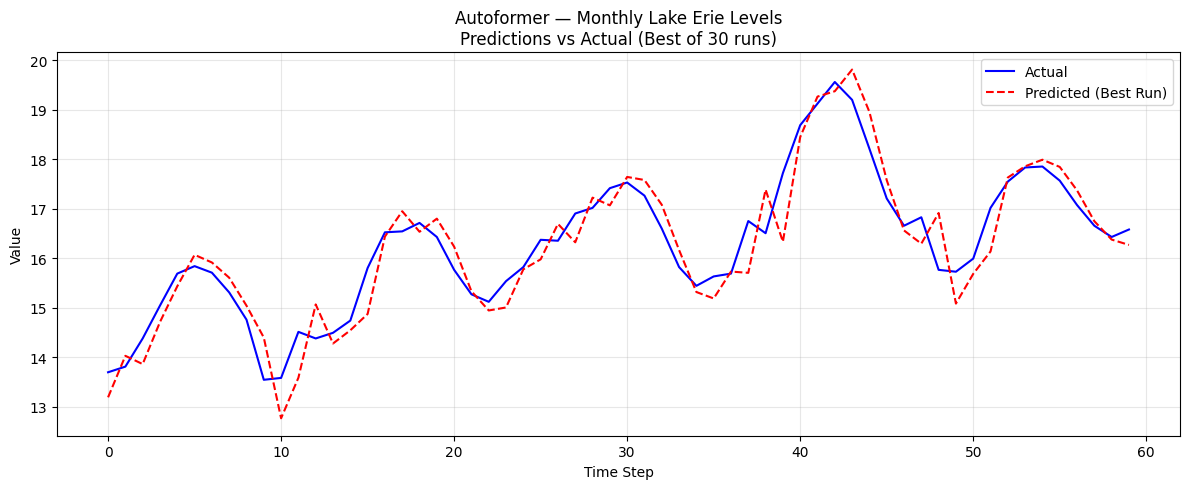

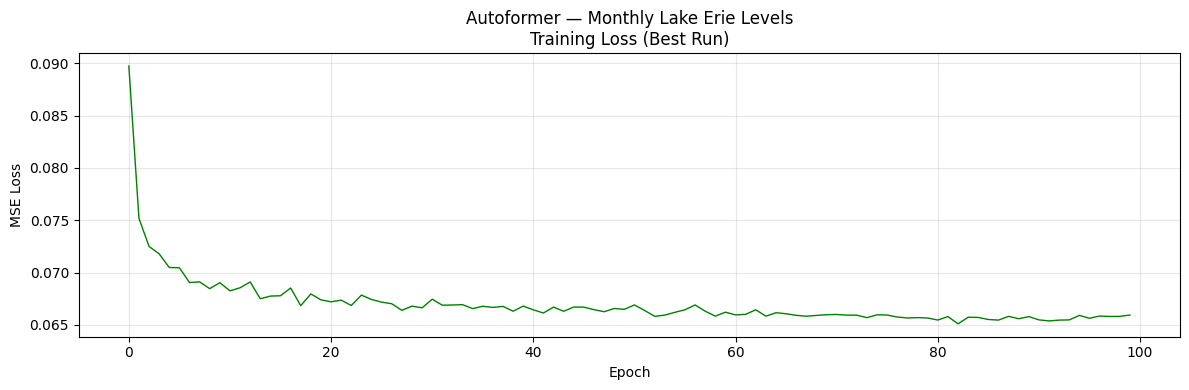

=== Best Run Metrics ===
RMSE: 0.502954
MSE:  0.252963
NMSE: 0.0019092250


In [22]:
# ============================================================
# Predictions vs Actual (Best Run)
# ============================================================

actual = raw_values[-60:]
best_predictions = all_predictions[best_idx]

plt.figure(figsize=(12, 5))
plt.plot(actual, label='Actual', color='blue', linewidth=1.5)
plt.plot(best_predictions, label='Predicted (Best Run)', color='red',
         linewidth=1.5, linestyle='--')
plt.title('Autoformer — Monthly Lake Erie Levels\nPredictions vs Actual (Best of 30 runs)')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Loss Curve (Best Run)
# ============================================================

plt.figure(figsize=(12, 4))
plt.plot(all_losses[best_idx], color='green', linewidth=1.0)
plt.title('Autoformer — Monthly Lake Erie Levels\nTraining Loss (Best Run)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Final Metrics Summary
# ============================================================

print('=== Best Run Metrics ===')
print(f'RMSE: {all_rmse[best_idx]:.6f}')
print(f'MSE:  {all_mse[best_idx]:.6f}')
print(f'NMSE: {all_nmse[best_idx]:.10f}')

## Export Predictions

In [23]:
# ============================================================
# Save Predictions to CSV
# ============================================================

actual = raw_values[-60:]
results_df = pd.DataFrame({
    'Actual': actual,
    'Predicted_BestRun': all_predictions[best_idx],
})
for i in range(30):
    results_df[f'Predicted_Run_{i+1}'] = all_predictions[i]

csv_filename = 'Autoformer_LakeErie_predictions.csv'
results_df.to_csv(csv_filename, index=False)
print(f'Predictions saved to {csv_filename}')

Predictions saved to Autoformer_LakeErie_predictions.csv


## Observations

### Autoformer on Monthly Lake Erie Levels

**Run the notebook to generate results and fill in observations:**

1. **Prediction Quality**: Compare RMSE/MSE/NMSE with LSTM-SNP variants
2. **Training Stability**: Examine loss curves for convergence behavior
3. **Prediction Tracking**: Assess how well predictions track actual values
4. **Computational Cost**: Compare training time with LSTM-SNP
5. **Model Size**: Note parameter count vs LSTM-SNP (~361 params)

*After running all 5 model notebooks per dataset, perform cross-model comparison to evaluate
whether Transformer architectures improve over LSTM-SNP for these time series datasets.*

In [ ]:
# ============================================================
# NOTEBOOK TIMER — END
# ============================================================
_NOTEBOOK_END_TIME = _timer_module.time()
_NOTEBOOK_ELAPSED = _NOTEBOOK_END_TIME - _NOTEBOOK_START_TIME
_hours, _rem = divmod(_NOTEBOOK_ELAPSED, 3600)
_minutes, _seconds = divmod(_rem, 60)
print(f"\nTotal notebook execution time: {int(_hours)}h {int(_minutes)}m {_seconds:.2f}s")
print(f"Total seconds: {_NOTEBOOK_ELAPSED:.2f}")
